# 🧠 Bayesian CNN dengan MC Dropout — Diabetic Retinopathy Classifier

Notebook trainer end-to-end untuk melatih **Bayesian CNN** menggunakan teknik **Monte Carlo (MC) Dropout**
(Gal & Ghahramani, 2016 — *"Dropout as a Bayesian Approximation"*) untuk klasifikasi tingkat keparahan
**Diabetic Retinopathy (DR)** dari citra fundus retina.

MC Dropout memungkinkan model mengestimasi **ketidakpastian prediksi (uncertainty)** — penting untuk
aplikasi medis, karena model perlu tahu kapan ia "tidak yakin" agar kasus tersebut bisa dirujuk ke
dokter spesialis, bukan diputuskan secara otomatis.

## Isi notebook ini
1. Setup & konfigurasi
2. Dataset & augmentasi (kompatibel dengan format APTOS 2019 / dataset DR lain)
3. Arsitektur Bayesian CNN — pilihan custom CNN ringan **atau** backbone ResNet18 pretrained, dengan Dropout di beberapa titik
4. Loop training + validasi, dengan tracking **Quadratic Weighted Kappa** (metrik standar untuk grading DR)
5. Inference MC Dropout: prediksi rata-rata, *predictive entropy* (total uncertainty), dan *mutual information* (epistemic uncertainty / BALD score)
6. Visualisasi: kurva training, confusion matrix, distribusi uncertainty, uncertainty-rejection curve
7. Simpan model & konfigurasi

## Format data yang diharapkan
- `CONFIG.CSV_PATH` → file CSV dengan kolom `id_code` (nama file citra tanpa ekstensi) dan `diagnosis` (label 0–4)
- `CONFIG.DATA_DIR` → folder berisi citra fundus, mis. `id_code.png`
- Label DR: `0 = No DR`, `1 = Mild`, `2 = Moderate`, `3 = Severe`, `4 = Proliferative DR`

> **Catatan:** Jika `CONFIG.CSV_PATH` / `CONFIG.DATA_DIR` tidak ditemukan, notebook otomatis memakai
> **dataset sintetis** agar seluruh pipeline tetap bisa dijalankan dan diverifikasi tanpa data asli.
> Ganti dengan data DR asli (mis. [APTOS 2019 Blindness Detection](https://www.kaggle.com/c/aptos2019-blindness-detection))
> untuk training yang sesungguhnya.

In [ ]:
# Jalankan sel ini jika package berikut belum terpasang di environment Anda
# (biasanya sudah tersedia di Google Colab)
# !pip install torch torchvision scikit-learn pandas matplotlib seaborn tqdm pillow -q

In [ ]:
import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms, models

from sklearn.metrics import cohen_kappa_score, confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

sns.set_style("whitegrid")


def set_seed(seed: int = 42):
    """Set semua random seed agar hasil reproducible."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {DEVICE}")

Menggunakan device: cuda


## ⚙️ Konfigurasi

Semua hyperparameter dan path dikumpulkan di satu tempat agar mudah diubah.

In [ ]:
import kagglehub
from pathlib import Path

# Unduh dataset — path akan otomatis mengarah ke folder cache lokal kagglehub
dataset_path = Path(kagglehub.dataset_download("sovitrath/diabetic-retinopathy-224x224-2019-data"))
print("Dataset diunduh ke:", dataset_path)

# Cari otomatis file CSV & folder citra di dalamnya (jaga-jaga kalau strukturnya bernested)
csv_candidates = sorted(dataset_path.rglob("*.csv"))
img_dir_candidates = sorted({
    p.parent for p in dataset_path.rglob("*")
    if p.suffix.lower() in (".png", ".jpg", ".jpeg")
})

print("CSV ditemukan:")
for c in csv_candidates:
    print("  -", c)

print("Folder citra ditemukan:")
for d in img_dir_candidates:
    n_img = len(list(d.glob("*")))
    print(f"  - {d}  ({n_img} file)")

Using Colab cache for faster access to the 'diabetic-retinopathy-224x224-2019-data' dataset.
Dataset diunduh ke: /kaggle/input/diabetic-retinopathy-224x224-2019-data
CSV ditemukan:
  - /kaggle/input/diabetic-retinopathy-224x224-2019-data/train.csv
Folder citra ditemukan:
  - /kaggle/input/diabetic-retinopathy-224x224-2019-data/colored_images/Mild  (370 file)
  - /kaggle/input/diabetic-retinopathy-224x224-2019-data/colored_images/Moderate  (999 file)
  - /kaggle/input/diabetic-retinopathy-224x224-2019-data/colored_images/No_DR  (1805 file)
  - /kaggle/input/diabetic-retinopathy-224x224-2019-data/colored_images/Proliferate_DR  (295 file)
  - /kaggle/input/diabetic-retinopathy-224x224-2019-data/colored_images/Severe  (193 file)


In [ ]:
class CONFIG:
    # --- Path data ---
    DATA_DIR = "data/colored_images"       # folder berisi citra fundus
    CSV_PATH = "data/train.csv"          # csv dengan kolom: id_code, diagnosis
    IMG_EXT = ".png"                     # ekstensi file citra

    # --- Data ---
    NUM_CLASSES = 5                      # 0: No DR, 1: Mild, 2: Moderate, 3: Severe, 4: Proliferative DR
    IMG_SIZE = 224
    VAL_SPLIT = 0.2
    BATCH_SIZE = 32
    NUM_WORKERS = 2

    # --- Model ---
    USE_PRETRAINED_BACKBONE = True       # True: ResNet18 pretrained, False: custom CNN ringan (offline)
    DROPOUT_RATE = 0.3                   # p untuk MC Dropout
    FREEZE_BACKBONE = False              # bekukan bobot backbone (transfer learning penuh vs fine-tune)

    # --- Training ---
    EPOCHS = 25
    LR = 3e-4
    WEIGHT_DECAY = 1e-4
    EARLY_STOPPING_PATIENCE = 5

    # --- Bayesian / MC Dropout inference ---
    MC_SAMPLES = 30                      # jumlah forward pass stokastik saat inference

    # --- Output ---
    CHECKPOINT_DIR = "checkpoints"
    BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "best_bayesian_cnn.pt")

    SEED = 42


os.makedirs(CONFIG.CHECKPOINT_DIR, exist_ok=True)
CLASS_NAMES = ["No DR", "Mild", "Moderate", "Severe", "Proliferative"][:CONFIG.NUM_CLASSES]

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sovitrath/diabetic-retinopathy-224x224-2019-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'diabetic-retinopathy-224x224-2019-data' dataset.
Path to dataset files: /kaggle/input/diabetic-retinopathy-224x224-2019-data


## 📂 Dataset

`DiabeticRetinopathyDataset` membaca citra asli sesuai CSV. `SyntheticRetinaDataset` adalah pengganti
sementara (noise berlabel) yang HANYA dipakai untuk memverifikasi pipeline berjalan tanpa data asli —
jangan dipakai untuk klaim performa model.

In [ ]:
CONFIG.DATA_DIR = "/kaggle/input/diabetic-retinopathy-224x224-2019-data/colored_images"
# CONFIG.CSV_PATH tidak dipakai lagi untuk sumber data ini —
# label sudah terkandung di nama folder, train.csv jadi redundan untuk keperluan ini.

# Urutan HARUS sesuai tingkat keparahan DR (bukan alfabetis!)
CLASS_TO_IDX = {
    "No_DR": 0,
    "Mild": 1,
    "Moderate": 2,
    "Severe": 3,
    "Proliferate_DR": 4,
}
CLASS_NAMES = ["No DR", "Mild", "Moderate", "Severe", "Proliferative"]


class FolderBasedRetinaDataset(Dataset):
    """Dataset untuk struktur 'colored_images/<NamaKelas>/*.png'."""

    def __init__(self, samples, transform=None):
        self.samples = samples                       # list of (filepath, label)
        self.labels = [lbl for _, lbl in samples]     # dipakai oleh compute_class_weights
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label


def scan_colored_images(data_dir, class_to_idx):
    data_dir = Path(data_dir)
    samples = []
    for class_name, label in class_to_idx.items():
        for img_path in (data_dir / class_name).glob("*"):
            if img_path.suffix.lower() in (".png", ".jpg", ".jpeg"):
                samples.append((str(img_path), label))
    return samples

In [ ]:
class DiabeticRetinopathyDataset(Dataset):
    """
    Dataset untuk citra fundus Diabetic Retinopathy.
    Mengharapkan dataframe dengan kolom:
      - 'id_code'  : nama file citra (tanpa ekstensi)
      - 'diagnosis': label kelas (0-4)
    """

    def __init__(self, dataframe: pd.DataFrame, img_dir: str, transform=None, img_ext=".png"):
        self.df = dataframe.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.transform = transform
        self.img_ext = img_ext

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.img_dir / f"{row['id_code']}{self.img_ext}"
        image = Image.open(img_path).convert("RGB")
        label = int(row["diagnosis"])

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
class SyntheticRetinaDataset(Dataset):
    """
    Dataset sintetis (citra noise berwarna + label berbobot) — dipakai HANYA agar seluruh
    pipeline notebook ini bisa dijalankan end-to-end tanpa data asli. Ganti dengan
    DiabeticRetinopathyDataset + data asli Anda untuk training sesungguhnya.
    """

    def __init__(self, n_samples=500, img_size=224, num_classes=5, transform=None, seed=42):
        rng = np.random.default_rng(seed)
        # distribusi label dibuat mirip DR asli: kelas "No DR" paling dominan
        class_probs = np.array([0.5, 0.15, 0.2, 0.1, 0.05][:num_classes])
        class_probs = class_probs / class_probs.sum()
        self.labels = rng.choice(num_classes, size=n_samples, p=class_probs)
        self.img_size = img_size
        self.transform = transform
        self.seed = seed

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        rng = np.random.default_rng(self.seed + idx)
        label = int(self.labels[idx])
        # noise dasar + shift warna tergantung label supaya ada sinyal untuk dipelajari model
        arr = rng.normal(loc=100 + label * 15, scale=40, size=(self.img_size, self.img_size, 3))
        arr = np.clip(arr, 0, 255).astype(np.uint8)
        image = Image.fromarray(arr)

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((CONFIG.IMG_SIZE, CONFIG.IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((CONFIG.IMG_SIZE, CONFIG.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [ ]:
expected_subfolders = all(
    (Path(CONFIG.DATA_DIR) / c).is_dir() for c in CLASS_TO_IDX
)

if expected_subfolders:
    print("Dataset asli ditemukan (struktur per-folder kelas) -> menggunakan data DR sesungguhnya.")
    all_samples = scan_colored_images(CONFIG.DATA_DIR, CLASS_TO_IDX)
    labels_for_split = [lbl for _, lbl in all_samples]

    train_samples, val_samples = train_test_split(
        all_samples, test_size=CONFIG.VAL_SPLIT, stratify=labels_for_split, random_state=CONFIG.SEED
    )
    train_dataset = FolderBasedRetinaDataset(train_samples, transform=train_transform)
    val_dataset = FolderBasedRetinaDataset(val_samples, transform=val_transform)
else:
    print("Folder kelas tidak ditemukan -> menggunakan dataset sintetis sebagai demo pipeline.")
    n_total = 600
    n_val = int(n_total * CONFIG.VAL_SPLIT)
    n_train = n_total - n_val
    train_dataset = SyntheticRetinaDataset(n_samples=n_train, img_size=CONFIG.IMG_SIZE,
                                            num_classes=CONFIG.NUM_CLASSES, transform=train_transform, seed=1)
    val_dataset = SyntheticRetinaDataset(n_samples=n_val, img_size=CONFIG.IMG_SIZE,
                                          num_classes=CONFIG.NUM_CLASSES, transform=val_transform, seed=2)

train_loader = DataLoader(train_dataset, batch_size=CONFIG.BATCH_SIZE, shuffle=True,
                           num_workers=CONFIG.NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG.BATCH_SIZE, shuffle=False,
                         num_workers=CONFIG.NUM_WORKERS, pin_memory=True)

print(f"Jumlah data train: {len(train_dataset)} | Jumlah data val: {len(val_dataset)}")

Dataset asli ditemukan (struktur per-folder kelas) -> menggunakan data DR sesungguhnya.
Jumlah data train: 2929 | Jumlah data val: 733


## 🏗️ Arsitektur: Bayesian CNN via MC Dropout

Ide inti MC Dropout (Gal & Ghahramani, 2016): sebuah CNN dengan layer `Dropout` yang dilatih seperti
biasa, secara matematis setara dengan **variational approximation** terhadap Bayesian Neural Network.
Konsekuensinya: jika saat *inference* kita **tetap mengaktifkan dropout** (bukan mematikannya seperti
`model.eval()` normal) dan melakukan **beberapa forward pass**, distribusi hasilnya bisa dipakai untuk
mengestimasi ketidakpastian model — tanpa perlu mengubah arsitektur dasar CNN.

Dua pilihan backbone disediakan:
- **`BayesianResNet`** — ResNet18 pretrained ImageNet + head classifier dengan Dropout (butuh koneksi internet untuk mengunduh bobot pretrained saat pertama kali dijalankan).
- **`LightBayesianCNN`** — CNN ringan dari awal, sepenuhnya offline, cocok untuk eksperimen cepat / tanpa GPU besar.

Pilih lewat `CONFIG.USE_PRETRAINED_BACKBONE`.

In [ ]:
class LightBayesianCNN(nn.Module):
    """
    CNN ringan dari awal (tanpa pretrained weights) dengan Dropout spasial
    di setiap blok konvolusi + Dropout di classifier head.
    """

    def __init__(self, num_classes=5, dropout_rate=0.3):
        super().__init__()

        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
                nn.Dropout2d(dropout_rate),
            )

        self.features = nn.Sequential(
            conv_block(3, 32),
            conv_block(32, 64),
            conv_block(64, 128),
            conv_block(128, 256),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)

In [ ]:
class BayesianResNet(nn.Module):
    """
    Backbone ResNet18 pretrained (ImageNet) + Dropout pada classifier head.
    Backbone bisa dibekukan (freeze) untuk transfer learning yang lebih stabil
    pada dataset medis berukuran kecil-menengah.
    """

    def __init__(self, num_classes=5, dropout_rate=0.3, freeze_backbone=False):
        super().__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        in_features = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(in_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)


def build_model():
    if CONFIG.USE_PRETRAINED_BACKBONE:
        model = BayesianResNet(num_classes=CONFIG.NUM_CLASSES, dropout_rate=CONFIG.DROPOUT_RATE,
                                freeze_backbone=CONFIG.FREEZE_BACKBONE)
    else:
        model = LightBayesianCNN(num_classes=CONFIG.NUM_CLASSES, dropout_rate=CONFIG.DROPOUT_RATE)
    return model.to(DEVICE)


model = build_model()
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model dibangun. Jumlah parameter trainable: {n_params:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 151MB/s]


Model dibangun. Jumlah parameter trainable: 11,309,125


## 🎯 Loss Function & Optimizer

Dataset DR umumnya sangat imbalanced (kelas "No DR" mendominasi), sehingga bobot kelas (inverse-frequency)
diterapkan pada `CrossEntropyLoss` agar model tidak bias ke kelas mayoritas.

In [ ]:
def compute_class_weights(dataset, num_classes):
    """Hitung bobot kelas terbalik dari frekuensi, untuk menangani imbalance data DR."""
    if hasattr(dataset, "df"):
        labels = dataset.df["diagnosis"].values
    elif hasattr(dataset, "labels"):
        labels = dataset.labels
    else:
        labels = [dataset[i][1] for i in range(len(dataset))]

    counts = np.array([np.sum(np.array(labels) == c) for c in range(num_classes)], dtype=np.float64)
    counts = np.clip(counts, 1, None)
    weights = counts.sum() / (num_classes * counts)
    return torch.tensor(weights, dtype=torch.float32)


class_weights = compute_class_weights(train_dataset, CONFIG.NUM_CLASSES).to(DEVICE)
print("Bobot kelas:", class_weights.cpu().numpy().round(3))

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG.LR, weight_decay=CONFIG.WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG.EPOCHS)

Bobot kelas: [0.406 1.979 0.733 3.804 2.482]


## 📊 Metrik & Training Loop

**Quadratic Weighted Kappa (QWK)** adalah metrik standar untuk grading DR karena label bersifat ordinal
(kesalahan prediksi antar kelas yang jauh, mis. No DR vs Proliferative, dihukum lebih berat daripada
antar kelas berdekatan).

In [ ]:
def quadratic_weighted_kappa(y_true, y_pred, num_classes=5):
    return cohen_kappa_score(y_true, y_pred, weights="quadratic", labels=list(range(num_classes)))


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, all_preds, all_labels = 0.0, [], []

    pbar = tqdm(loader, desc="Training", leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        pbar.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_kappa = quadratic_weighted_kappa(all_labels, all_preds, CONFIG.NUM_CLASSES)
    return epoch_loss, epoch_acc, epoch_kappa


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    running_loss, all_preds, all_labels = 0.0, [], []

    pbar = tqdm(loader, desc="Validasi", leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        pbar.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_kappa = quadratic_weighted_kappa(all_labels, all_preds, CONFIG.NUM_CLASSES)
    return epoch_loss, epoch_acc, epoch_kappa

In [ ]:
history = {"train_loss": [], "train_acc": [], "train_kappa": [],
           "val_loss": [], "val_acc": [], "val_kappa": []}

best_kappa = -np.inf
epochs_no_improve = 0
best_model_state = None

for epoch in range(1, CONFIG.EPOCHS + 1):
    train_loss, train_acc, train_kappa = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, val_kappa = validate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_kappa"].append(train_kappa)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_kappa"].append(val_kappa)

    print(f"Epoch {epoch:02d}/{CONFIG.EPOCHS} | "
          f"Train Loss {train_loss:.4f} Acc {train_acc:.4f} Kappa {train_kappa:.4f} | "
          f"Val Loss {val_loss:.4f} Acc {val_acc:.4f} Kappa {val_kappa:.4f}")

    if val_kappa > best_kappa:
        best_kappa = val_kappa
        epochs_no_improve = 0
        best_model_state = copy.deepcopy(model.state_dict())
        torch.save({
            "model_state_dict": best_model_state,
            "config": {k: v for k, v in vars(CONFIG).items() if not k.startswith("__")},
            "val_kappa": val_kappa,
            "epoch": epoch,
        }, CONFIG.BEST_MODEL_PATH)
        print(f"   -> Model terbaik disimpan (Val Kappa: {val_kappa:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= CONFIG.EARLY_STOPPING_PATIENCE:
            print(f"Early stopping di epoch {epoch} "
                  f"(tidak ada peningkatan selama {CONFIG.EARLY_STOPPING_PATIENCE} epoch).")
            break

if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"\nModel terbaik dimuat kembali (Val Kappa: {best_kappa:.4f})")

Training:   0%|          | 0/91 [00:00<?, ?it/s]

Validasi:   0%|          | 0/23 [00:00<?, ?it/s]

Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x78d9ac127420>Traceback (most recent call last):
Exception ignored in:   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
<function _MultiProcessingDataLoaderIter.__del__ at 0x78d9ac127420>    
self._shutdown_workers()
Traceback (most recent call last):
Exception ignored in:   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
<function _MultiProcessingDataLoaderIter.__del__ at 0x78d9ac127420>    
    if w.is_alive():
Traceback (most recent call last):
self._shutdown_workers() 
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
     self

Epoch 01/25 | Train Loss 1.1531 Acc 0.6346 Kappa 0.7124 | Val Loss 1.0877 Acc 0.7203 Kappa 0.8145
   -> Model terbaik disimpan (Val Kappa: 0.8145)


Training:   0%|          | 0/91 [00:00<?, ?it/s]

...

Validasi:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 24/25 | Train Loss 0.2752 Acc 0.9214 Kappa 0.9571 | Val Loss 0.8698 Acc 0.8472 Kappa 0.9072


Training:   0%|          | 0/91 [00:00<?, ?it/s]

Validasi:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 25/25 | Train Loss 0.2595 Acc 0.9262 Kappa 0.9570 | Val Loss 0.8633 Acc 0.8499 Kappa 0.9129
   -> Model terbaik disimpan (Val Kappa: 0.9129)

Model terbaik dimuat kembali (Val Kappa: 0.9129)


## 📈 Kurva Training

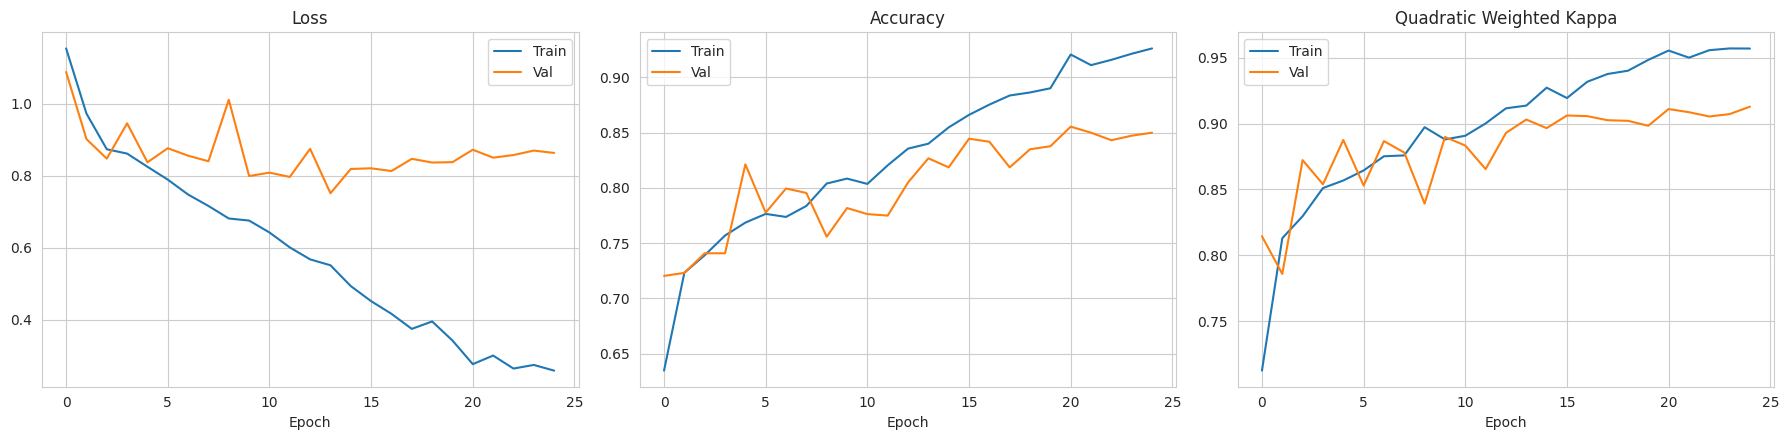

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"], label="Val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_acc"], label="Train")
axes[1].plot(history["val_acc"], label="Val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].plot(history["train_kappa"], label="Train")
axes[2].plot(history["val_kappa"], label="Val")
axes[2].set_title("Quadratic Weighted Kappa")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.tight_layout()
plt.show()

## 🎲 MC Dropout Inference: Estimasi Uncertainty

Untuk setiap citra, dilakukan **T forward pass stokastik** (dropout tetap aktif). Dari T sampel prediksi
dihitung:

- **Predictive entropy** — total uncertainty dari rata-rata prediksi
- **Expected entropy** — rata-rata entropy dari tiap sampel individual (aleatoric / noise data)
- **Mutual information** = predictive entropy − expected entropy → **epistemic uncertainty** (BALD score),
  yaitu ketidakpastian yang murni berasal dari ketidaktahuan model (bisa dikurangi dengan lebih banyak data),
  bukan dari noise inheren pada citra.

In [ ]:
def enable_mc_dropout(model):
    """
    Aktifkan mode stokastik HANYA pada layer Dropout, sementara layer lain
    (BatchNorm, dll.) tetap dalam mode eval(). Ini cara standar untuk melakukan
    MC Dropout inference: panggil model.eval() dulu, lalu paksa layer dropout
    kembali ke mode train() agar tetap stokastik saat sampling.
    """
    for module in model.modules():
        if isinstance(module, (nn.Dropout, nn.Dropout2d)):
            module.train()


@torch.no_grad()
def mc_dropout_predict(model, images, T=CONFIG.MC_SAMPLES):
    """
    Melakukan T forward pass stokastik untuk satu batch citra.

    Returns
    -------
    mean_probs          : Tensor [batch, num_classes] -> prediksi rata-rata (softmax)
    predictive_entropy  : Tensor [batch]               -> total uncertainty
    mutual_info         : Tensor [batch]               -> epistemic uncertainty (BALD)
    all_probs           : Tensor [T, batch, num_classes] -> seluruh sample mentah
    """
    model.eval()
    enable_mc_dropout(model)

    images = images.to(DEVICE)
    probs_samples = []

    for _ in range(T):
        logits = model(images)
        probs = F.softmax(logits, dim=1)
        probs_samples.append(probs.unsqueeze(0))

    all_probs = torch.cat(probs_samples, dim=0)          # [T, B, C]
    mean_probs = all_probs.mean(dim=0)                    # [B, C]

    predictive_entropy = -(mean_probs * torch.log(mean_probs + 1e-12)).sum(dim=1)

    sample_entropy = -(all_probs * torch.log(all_probs + 1e-12)).sum(dim=2)   # [T, B]
    expected_entropy = sample_entropy.mean(dim=0)                             # [B]

    mutual_info = predictive_entropy - expected_entropy

    return mean_probs.cpu(), predictive_entropy.cpu(), mutual_info.cpu(), all_probs.cpu()

In [ ]:
def evaluate_with_uncertainty(model, loader, T=CONFIG.MC_SAMPLES):
    all_mean_probs, all_pred_entropy, all_mutual_info, all_labels = [], [], [], []

    for images, labels in tqdm(loader, desc="MC Dropout Inference"):
        mean_probs, pred_entropy, mutual_info, _ = mc_dropout_predict(model, images, T=T)
        all_mean_probs.append(mean_probs)
        all_pred_entropy.append(pred_entropy)
        all_mutual_info.append(mutual_info)
        all_labels.extend(labels.numpy())

    all_mean_probs = torch.cat(all_mean_probs, dim=0).numpy()
    all_pred_entropy = torch.cat(all_pred_entropy, dim=0).numpy()
    all_mutual_info = torch.cat(all_mutual_info, dim=0).numpy()
    all_preds = all_mean_probs.argmax(axis=1)
    all_labels = np.array(all_labels)

    return all_preds, all_labels, all_mean_probs, all_pred_entropy, all_mutual_info


preds, labels_true, mean_probs, pred_entropy, mutual_info = evaluate_with_uncertainty(model, val_loader)

print(f"Akurasi (MC Dropout mean)  : {accuracy_score(labels_true, preds):.4f}")
print(f"Quadratic Weighted Kappa   : {quadratic_weighted_kappa(labels_true, preds, CONFIG.NUM_CLASSES):.4f}")
print("\nClassification Report:\n", classification_report(labels_true, preds, digits=3))

MC Dropout Inference:   0%|          | 0/23 [00:00<?, ?it/s]

Akurasi (MC Dropout mean)  : 0.8527
Quadratic Weighted Kappa   : 0.9116

Classification Report:
               precision    recall  f1-score   support

           0      0.976     0.994     0.985       361
           1      0.651     0.730     0.688        74
           2      0.827     0.765     0.795       200
           3      0.556     0.641     0.595        39
           4      0.654     0.576     0.613        59

    accuracy                          0.853       733
   macro avg      0.733     0.741     0.735       733
weighted avg      0.854     0.853     0.852       733



## 🔍 Confusion Matrix

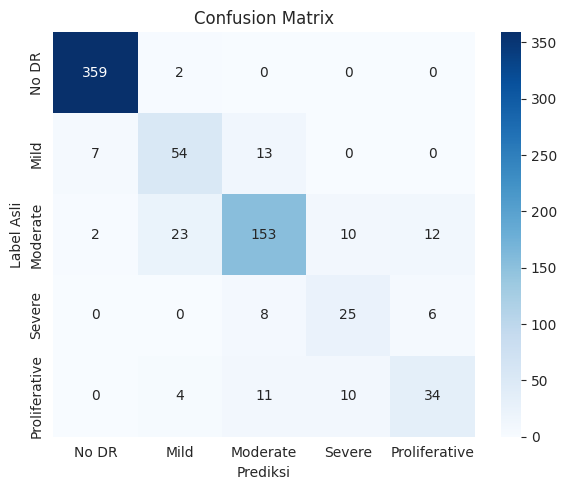

In [ ]:
cm = confusion_matrix(labels_true, preds, labels=list(range(CONFIG.NUM_CLASSES)))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Prediksi")
plt.ylabel("Label Asli")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

## 📉 Distribusi Uncertainty: Benar vs Salah

Model Bayesian yang baik seharusnya menunjukkan **uncertainty lebih tinggi pada prediksi yang salah**
dibanding prediksi yang benar.

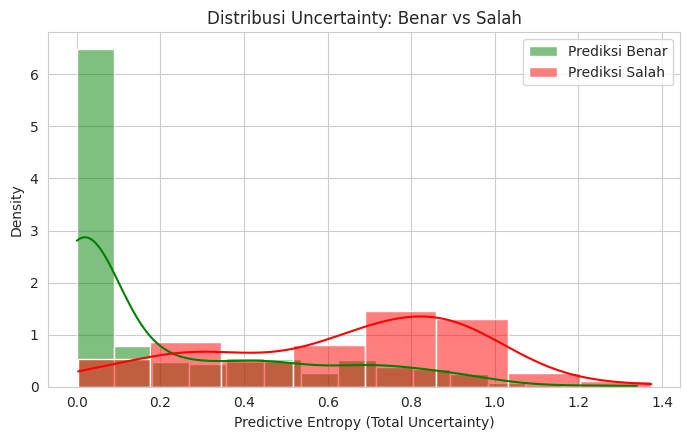

In [ ]:
correct_mask = preds == labels_true

plt.figure(figsize=(7, 4.5))
sns.histplot(pred_entropy[correct_mask], color="green", label="Prediksi Benar",
             kde=True, stat="density", alpha=0.5)
sns.histplot(pred_entropy[~correct_mask], color="red", label="Prediksi Salah",
             kde=True, stat="density", alpha=0.5)
plt.xlabel("Predictive Entropy (Total Uncertainty)")
plt.ylabel("Density")
plt.title("Distribusi Uncertainty: Benar vs Salah")
plt.legend()
plt.tight_layout()
plt.show()

## 🚦 Uncertainty-Rejection Curve

Simulasi skenario *"rujuk ke dokter spesialis jika model tidak yakin"*: kasus dengan uncertainty
tertinggi ditolak secara bertahap, lalu akurasi dihitung ulang pada sisa data. Kurva yang naik menunjukkan
bahwa estimasi uncertainty benar-benar informatif.

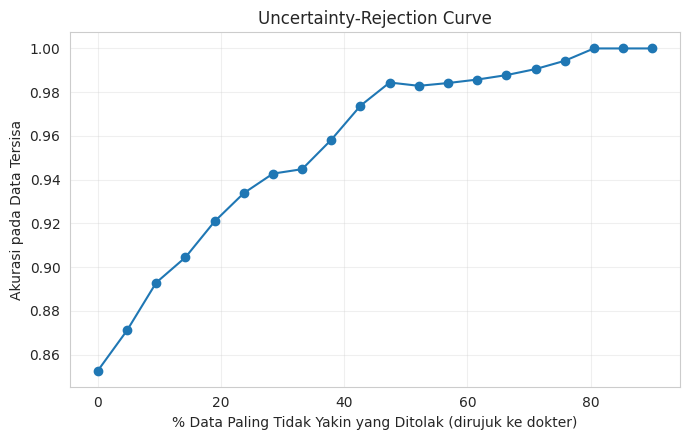

In [ ]:
def uncertainty_rejection_curve(preds, labels_true, uncertainty, steps=20):
    order = np.argsort(uncertainty)  # urut dari yang paling yakin (uncertainty rendah)
    n = len(order)
    fractions, accuracies = [], []

    for frac in np.linspace(0, 0.9, steps):
        keep_n = int(n * (1 - frac))
        if keep_n < 1:
            break
        idx = order[:keep_n]
        acc = accuracy_score(labels_true[idx], preds[idx])
        fractions.append(frac)
        accuracies.append(acc)

    return np.array(fractions), np.array(accuracies)


frac_rejected, acc_at_frac = uncertainty_rejection_curve(preds, labels_true, pred_entropy)

plt.figure(figsize=(7, 4.5))
plt.plot(frac_rejected * 100, acc_at_frac, marker="o")
plt.xlabel("% Data Paling Tidak Yakin yang Ditolak (dirujuk ke dokter)")
plt.ylabel("Akurasi pada Data Tersisa")
plt.title("Uncertainty-Rejection Curve")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 🖼️ Inference pada Satu Citra dengan Uncertainty

In [ ]:
def predict_single_image(model, image_tensor, class_names, T=CONFIG.MC_SAMPLES):
    """
    Prediksi satu citra dengan estimasi uncertainty.
    image_tensor: tensor [3, H, W] yang SUDAH melalui val_transform.
    """
    batch = image_tensor.unsqueeze(0)
    mean_probs, pred_entropy, mutual_info, all_probs = mc_dropout_predict(model, batch, T=T)

    mean_probs = mean_probs[0].numpy()
    pred_class = int(mean_probs.argmax())
    std_per_class = all_probs[:, 0, :].std(dim=0).numpy()

    print(f"Prediksi: {class_names[pred_class]} (kelas {pred_class})")
    print(f"Predictive Entropy (total uncertainty)    : {pred_entropy.item():.4f}")
    print(f"Mutual Information (epistemic uncertainty): {mutual_info.item():.4f}")
    print("\nDistribusi probabilitas per kelas (mean +/- std dari MC sampling):")
    for i, cname in enumerate(class_names):
        print(f"  {cname:15s}: {mean_probs[i]:.3f} +/- {std_per_class[i]:.3f}")

    return pred_class, mean_probs, pred_entropy.item(), mutual_info.item()


# Contoh penggunaan pada satu sampel dari validation set:
sample_image, sample_label = val_dataset[590]
print(f"Label asli: {CLASS_NAMES[sample_label]}\n")
_ = predict_single_image(model, sample_image, CLASS_NAMES)

Label asli: Moderate

Prediksi: Moderate (kelas 2)
Predictive Entropy (total uncertainty)    : 0.6582
Mutual Information (epistemic uncertainty): 0.0157

Distribusi probabilitas per kelas (mean +/- std dari MC sampling):
  No DR          : 0.001 +/- 0.001
  Mild           : 0.041 +/- 0.021
  Moderate       : 0.812 +/- 0.046
  Severe         : 0.028 +/- 0.013
  Proliferative  : 0.117 +/- 0.038


## 💾 Simpan Model & Konfigurasi

In [ ]:
final_save_path = os.path.join(CONFIG.CHECKPOINT_DIR, "bayesian_cnn_final.pt")
torch.save({
    "model_state_dict": model.state_dict(),
    "config": {k: v for k, v in vars(CONFIG).items() if not k.startswith("__")},
    "history": history,
    "best_val_kappa": best_kappa,
}, final_save_path)

print(f"Model final disimpan di: {final_save_path}")
print(f"Model terbaik (checkpoint) disimpan di: {CONFIG.BEST_MODEL_PATH}")

Model final disimpan di: checkpoints/bayesian_cnn_final.pt
Model terbaik (checkpoint) disimpan di: checkpoints/best_bayesian_cnn.pt


## ✅ Ringkasan & Langkah Selanjutnya

- **Ganti dataset sintetis** dengan data DR asli (mis. [APTOS 2019 Blindness Detection](https://www.kaggle.com/c/aptos2019-blindness-detection)) dengan mengisi `CONFIG.CSV_PATH` dan `CONFIG.DATA_DIR`.
- **`CONFIG.DROPOUT_RATE`** mempengaruhi trade-off antara akurasi dan kualitas estimasi uncertainty — coba beberapa nilai (0.2–0.5).
- **`CONFIG.MC_SAMPLES`** lebih besar (mis. 50–100) memberi estimasi uncertainty yang lebih stabil saat inference, dengan trade-off waktu komputasi.
- Untuk Bayesian CNN yang lebih formal (full variational inference, bukan hanya MC Dropout), pertimbangkan library seperti `torchbnn` atau `blitz-bayesian-pytorch` sebagai pembanding.
- Gunakan hasil `uncertainty_rejection_curve` untuk menentukan threshold uncertainty yang layak dipakai sebagai kriteria "rujuk ke dokter spesialis" pada sistem clinical decision support — bukan sebagai pengganti diagnosis dokter.